# MLS-SRTP Figures

This notebook generates figures from the Criterion benchmark results.

## Prerequisites: 

Run the benchmarks and copy results:
```bash
./run_end_to_end.sh
```

Or run individual benchmarks manually:
```bash
cargo bench --package mls-srtp-core --bench srtp_throughput_criterion
cargo bench --package mls-srtp-core --bench rekey
cargo bench --package mls-srtp-core --bench key_derivation
```

In [117]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Global matplotlib style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# All Criterion results are copied here by run_end_to_end.sh
CRITERION_DIR = Path('crates/mls-srtp-core/benches/results/criterion')

# SRTP throughput (encrypt/decrypt across 15 payload sizes)
RESULTS_DIR = CRITERION_DIR / 'srtp_throughput' / 'protect'
UNPROTECT_RESULTS_DIR = CRITERION_DIR / 'srtp_throughput' / 'unprotect'

# PEP throughput (CTR and CTR_CMAC-64 modes, encrypt/decrypt)
PEP_DIR = CRITERION_DIR / 'pep_throughput'

# MLS rekey (sender/receiver pipeline across group sizes)
REKEY_DIR = CRITERION_DIR / 'rekey'

# Key derivation (MLS export + SRTP KDF)
KEY_DERIVATION_DIR = CRITERION_DIR / 'key_derivation'

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

In [118]:
def load_criterion_results(results_dir: Path) -> dict:
    """Loads Criterion benchmark results from a directory of payload-size subdirs.
    
    Works for both SRTP and PEP benchmarks, i.e. any Criterion group where each
    subdirectory contains benchmark.json (with a throughput field and a label
    like "1424B_standard") and estimates.json (with mean/std_dev).
    
    Returns a dict mapping payload_size (int) -> {
        'label': str, 'payload_bytes': int, 'packet_bytes': int,
        'mean_ns': float, 'std_ns': float, 'throughput_gbps': float
    }
    """
    results = {}
    
    for entry in sorted(results_dir.iterdir()):
        
        # skipping the top-level "report/" folder (Criterion's summary HTML)
        if not entry.is_dir() or entry.name == 'report':
            continue
        
        # each benchmark run has benchmark.json (metadata) and estimates.json (stats)
        bench_path = entry / 'new' / 'benchmark.json'
        est_path = entry / 'new' / 'estimates.json'
        
        if not bench_path.exists() or not est_path.exists():
            continue
        
        with open(bench_path) as f:
            bench = json.load(f)
        with open(est_path) as f:
            estimates = json.load(f)
        
        label = bench['value_str']
        
        # criterion's "Bytes" throughput field = total packet size on the wire
        # (for SRTP: 12 B RTP header + payload + 16 B GCM tag)
        # (for PEP CTR: 12 B RTP header + payload)
        # (for PEP CTR+CMAC: 12 B RTP header + payload + 8 B CMAC tag)
        packet_bytes = bench['throughput']['Bytes']
        
        mean_ns = estimates['mean']['point_estimate']
        std_ns = estimates['std_dev']['point_estimate']
        
        # extracting the numeric payload size from the label 
        # (e.g. "1424B_standard" -> 1424)
        match = re.match(r'(\d+)B', label)
        if match:
            payload_size = int(match.group(1))
        else:
            continue
        
        # bits/ns = Gbps (since 1 bit/ns = 1 Gbps)
        throughput_gbps = (packet_bytes * 8) / mean_ns
        
        results[payload_size] = {
            'label': label,
            'payload_bytes': payload_size,
            'packet_bytes': packet_bytes,
            'mean_ns': mean_ns,
            'std_ns': std_ns,
            'throughput_gbps': throughput_gbps,
        }
    
    # sorting by payload size
    return dict(sorted(results.items()))


results = load_criterion_results(RESULTS_DIR)

print(f'Loaded {len(results)} benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       102.4        3.44 Gbps
     32B       106.1        4.52 Gbps
     40B       112.4        4.84 Gbps
     64B       109.6        6.71 Gbps
    128B       118.7       10.51 Gbps
    160B       127.4       11.80 Gbps
    256B       145.4       15.62 Gbps
    512B       158.5       27.25 Gbps
    800B       186.0       35.60 Gbps
   1024B       211.5       39.80 Gbps
   1200B       230.3       42.66 Gbps
   1424B       252.2       46.06 Gbps
   2048B       317.8       52.26 Gbps
   4096B       530.3       62.21 Gbps
   8924B      1038.4       68.97 Gbps


In [119]:
# Loading decryption (unprotect) results using the same loader function
unprotect_results = load_criterion_results(UNPROTECT_RESULTS_DIR)

print(f'Loaded {len(unprotect_results)} unprotect benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in unprotect_results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 unprotect benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       126.9        2.77 Gbps
     32B       126.8        3.79 Gbps
     40B       132.1        4.12 Gbps
     64B       127.6        5.77 Gbps
    128B       137.0        9.11 Gbps
    160B       144.5       10.41 Gbps
    256B       161.6       14.06 Gbps
    512B       197.1       21.92 Gbps
    800B       227.0       29.18 Gbps
   1024B       242.6       34.69 Gbps
   1200B       267.5       36.72 Gbps
   1424B       294.3       39.47 Gbps
   2048B       352.8       47.07 Gbps
   4096B       574.7       57.40 Gbps
   8924B      1179.6       60.71 Gbps


## Figure 1: SRTP Throughput vs. Uncompressed Video Bitrates

Throughput (Gbps) for SRTP `protect()` (encrypt) and `unprotect()` (decrypt)
across 15 payload sizes. Both operations are pure crypto (no network or
packet construction overhead). Reference lines show uncompressed video
bitrates (ST 2110, 4:2:2, 10-bit).

Data from Criterion results in `criterion/srtp_throughput/`.

In [120]:
# --- Uncompressed video bitrates (ST 2110, 4:2:2, 10-bit) ---
# These are reference bitrates from the table provided by the EBU. 
# They are used as horizontal reference lines in the throughput plot 
# to show how SRTP compares to real workloads.

video_formats = [
    # (label,       bitrate_gbps, resolution_group)
    ('720p50',       0.96,  '720p'),
    ('720p60',       1.15,  '720p'),
    ('1080p50',      2.15,  '1080p'),
    ('1080p60',      2.58,  '1080p'),
    ('2160p50',      8.60,  '2160p'),
    ('2160p60',     10.32,  '2160p'),
    ('2160p120',    20.65,  '2160p'),
    ('2160p300',    51.62,  '2160p'),
    ('4320p50',     34.41,  '4320p'),
    ('4320p60',     41.29,  '4320p'),
]

# Color scheme by resolution family
resolution_colors = {
    '720p':  '#27ae60',
    '1080p': '#2980b9',
    '2160p': '#e67e22',
    '4320p': '#8e44ad',
}

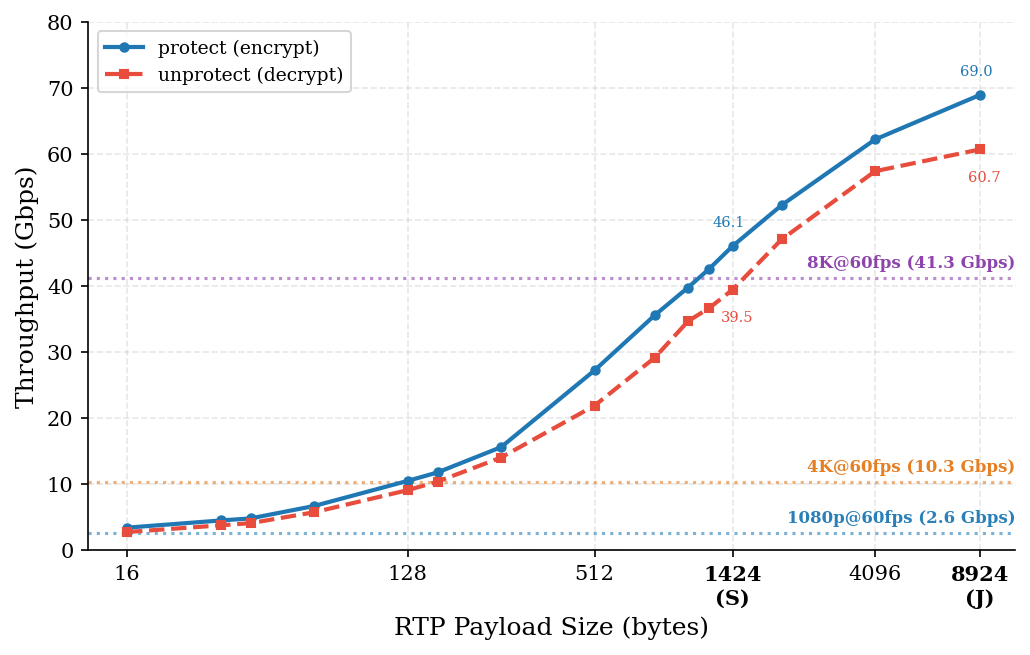

In [121]:
# Extracting sorted payload sizes and corresponding throughputs 
# from benchmark results
payload_sizes = np.array(list(results.keys()))
throughput_gbps = np.array([r['throughput_gbps'] for r in results.values()])

# decrypt throughput (same payload sizes since both benchmarks use same set)
unprotect_payload_sizes = np.array(list(unprotect_results.keys()))
unprotect_throughput_gbps = np.array([r['throughput_gbps'] for r in unprotect_results.values()])

fig, ax = plt.subplots(figsize=(7, 4.5))

# --- SRTP throughput curves ---
ax.plot(payload_sizes, throughput_gbps, 'o-', color='#1f77b4', linewidth=2,
        markersize=4, zorder=5, label='protect (encrypt)')
ax.plot(unprotect_payload_sizes, unprotect_throughput_gbps, 's--', color='#e74c3c',
        linewidth=2, markersize=4, zorder=5, label='unprotect (decrypt)')

# --- Value labels at the two MTU sizes ---
# encrypt above, decrypt below, consistent 8pt offset, colors match lines
pt_off = 10
for sz in [1424, 8924]:
    tp_enc = results[sz]['throughput_gbps']
    ax.annotate(f'{tp_enc:.1f}', (sz, tp_enc),
                textcoords='offset points', xytext=(-2, pt_off - 2),
                fontsize=7, ha='center', va='bottom', color='#1f77b4')
    tp_dec = unprotect_results[sz]['throughput_gbps']
    ax.annotate(f'{tp_dec:.1f}', (sz, tp_dec),
                textcoords='offset points', xytext=(+2, -pt_off),
                fontsize=7, ha='center', va='top', color='#e74c3c')

# --- Video bitrate reference lines ---
y_max = 80

display_formats = {
    '1080p60': '1080p',
    '2160p60': '4K',
    '4320p60': '8K',
}

for label, bitrate, res_group in video_formats:
    if label not in display_formats:
        continue
    display_label = display_formats[label]
    color = resolution_colors[res_group]
    ax.axhline(y=bitrate, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    ax.text(1.0, bitrate + 1.0, f'{display_label}@60fps ({bitrate:.1f} Gbps)',
            va='bottom', ha='right', fontsize=8, color=color, fontweight='bold',
            transform=ax.get_yaxis_transform())

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Throughput (Gbps)')

# (S) and (J) on a new line under 1424 and 8924
xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

ax.set_ylim(0, y_max)
ax.set_xlim(12, payload_sizes[-1] * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.png')
plt.show()

## Figure 2: SRTP Per-Packet Latency vs. Payload Size

Per-packet latency (ns) for SRTP `protect()` and `unprotect()` across all
15 payload sizes. This is the same benchmark data as Figure 1, showing latency instead of throughput.

Data from Criterion results in `criterion/srtp_throughput/`.

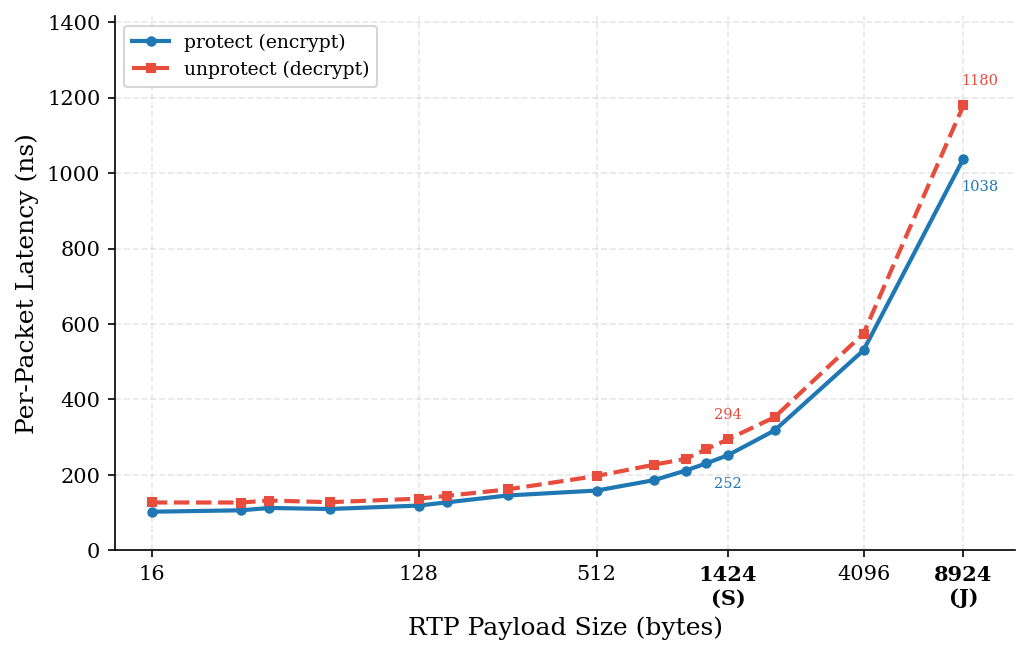

In [ ]:
# --- Figure 2: SRTP per-packet latency ---
# Same benchmark data as Figure 1, showing latency instead of throughput.

common_sizes = sorted(set(results.keys()) & set(unprotect_results.keys()))
lat_sizes = np.array(common_sizes)
protect_ns = np.array([results[sz]['mean_ns'] for sz in common_sizes])
unprotect_ns = np.array([unprotect_results[sz]['mean_ns'] for sz in common_sizes])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(lat_sizes, protect_ns, 'o-', color='#1f77b4', linewidth=2,
        markersize=4, zorder=5, label='protect (encrypt)')
ax.plot(lat_sizes, unprotect_ns, 's--', color='#e74c3c', linewidth=2,
        markersize=4, zorder=5, label='unprotect (decrypt)')

# --- Value labels at the two MTU sizes ---
pt_off = 10
for sz in [1424, 8924]:
    jumbo = sz == 8924;    
    ns_enc = results[sz]['mean_ns']
    ax.annotate(f'{ns_enc:.0f}', (sz, ns_enc),
                textcoords='offset points', xytext=(jumbo * 8, -pt_off - 7),
                fontsize=7, ha='center', va='bottom', color='#1f77b4')
    ns_dec = unprotect_results[sz]['mean_ns']
    ax.annotate(f'{ns_dec:.0f}', (sz, ns_dec),
                textcoords='offset points', xytext=(jumbo * 8, pt_off + 5),
                fontsize=7, ha='center', va='top', color='#e74c3c')

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Per-Packet Latency (ns)')

xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

ax.set_ylim(0, max(unprotect_ns) * 1.2)
ax.set_xlim(12, lat_sizes[-1] * 1.5)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_srtp_latency.pdf')
plt.savefig(FIGURES_DIR / 'fig2_srtp_latency.png')
plt.show()

## Table 1: SRTP Performance Summary

Key numbers for the two ST 2110-10 MTU sizes.

Data from Criterion results in `criterion/srtp_throughput/` and
`benches/results/mls_srtp_operations/results.md` (replay protection).

In [130]:
# --- Table 1: SRTP performance summary ---

# replay protection is constant at ~3.6 ns regardless of payload size
# (from benches/results/mls_srtp_operations/results.md)
replay_ns = 3.55

mtu_sizes = [1424, 8924]

# collecting protect/unprotect data for both MTU sizes
row_data = []
for sz in mtu_sizes:
    row_data.append((results[sz], unprotect_results[sz]))

def fmt_ns(ns):
    """Formats nanoseconds, switching to \u00b5s if >= 1000."""
    if ns >= 1000:
        return f'{ns/1000:.2f} \u00b5s'
    return f'{ns:.1f} ns'

metrics = [
    ('Encrypt latency',    [fmt_ns(row_data[i][0]['mean_ns']) for i in range(2)]),
    ('Decrypt latency',    [fmt_ns(row_data[i][1]['mean_ns']) for i in range(2)]),
    ('Replay  check',       [fmt_ns(replay_ns)] * 2),
    ('Encrypt throughput', [f'{row_data[i][0]["throughput_gbps"]:.1f} Gbps' for i in range(2)]),
    ('Decrypt throughput', [f'{row_data[i][1]["throughput_gbps"]:.1f} Gbps' for i in range(2)]),
]

print(f'{"Metric":<24s}  {"Standard MTU":>14s}  {"Jumbo MTU":>14s}')
print('-' * 56)
for name, vals in metrics:
    print(f'{name:<24s}  {vals[0]:>14s}  {vals[1]:>14s}')

Metric                      Standard MTU       Jumbo MTU
--------------------------------------------------------
Encrypt latency                 252.2 ns         1.04 µs
Decrypt latency                 294.3 ns         1.18 µs
Replay  check                     3.5 ns          3.5 ns
Encrypt throughput             46.1 Gbps       69.0 Gbps
Decrypt throughput             39.5 Gbps       60.7 Gbps


## Table 2: SRTP Packet Size Overhead

SRTP with AES-128-GCM adds a constant 16-byte authentication tag per packet
(RFC 7714). The 12-byte RTP header is authenticated but not encrypted.
The overhead is most significant for small audio packets and negligible
for large video payloads.

In [124]:
# --- Table 2: Packet size overhead ---


# RTP header is always 12 bytes (RFC 3550, no CSRCs or extensions).
RTP_HDR = 12   # bytes

# SRTP adds a fixed 16-byte GCM authentication tag to every packet.
GCM_TAG = 16   # bytes

# representative payload sizes with their use-case labels
overhead_sizes = [
    (40,   'Wideband speech'),
    (160,  'Fullband mono music'),
    (800,  'Video fragment (small)'),
    (1200, 'Video fragment (near-MTU)'),
    (1424, 'ST 2110 standard MTU'),
    (8924, 'ST 2110 jumbo MTU'),
]

print(f'{"Payload":<8s}  {"Use Case":<26s}  {"RTP":>6s}  {"SRTP":>6s}  {"Overhead":>9s}')
print('-' * 60)
for payload, use_case in overhead_sizes:
    rtp_size = RTP_HDR + payload
    srtp_size = rtp_size + GCM_TAG
    overhead_pct = GCM_TAG / rtp_size * 100
    print(f'{payload:>6d} B  {use_case:<26s}  {rtp_size:>5d} B  {srtp_size:>5d} B  {overhead_pct:>7.1f} %')

Payload   Use Case                       RTP    SRTP   Overhead
------------------------------------------------------------
    40 B  Wideband speech                52 B     68 B     30.8 %
   160 B  Fullband mono music           172 B    188 B      9.3 %
   800 B  Video fragment (small)        812 B    828 B      2.0 %
  1200 B  Video fragment (near-MTU)    1212 B   1228 B      1.3 %
  1424 B  ST 2110 standard MTU         1436 B   1452 B      1.1 %
  8924 B  ST 2110 jumbo MTU            8936 B   8952 B      0.2 %
